In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e12/sample_submission.csv
/kaggle/input/playground-series-s5e12/train.csv
/kaggle/input/playground-series-s5e12/test.csv


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression #LinearRegression
from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import (accuracy_score, confusion_matrix,
                            classification_report, roc_curve,
                            roc_auc_score, precision_score,
                            recall_score, f1_score)
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
data_path = '/kaggle/input/playground-series-s5e12/train.csv'
data = pd.read_csv(data_path)
data.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [4]:
data.drop('id',axis = 1, inplace=True)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 25 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 700000 non-null  int64  
 1   alcohol_consumption_per_week        700000 non-null  int64  
 2   physical_activity_minutes_per_week  700000 non-null  int64  
 3   diet_score                          700000 non-null  float64
 4   sleep_hours_per_day                 700000 non-null  float64
 5   screen_time_hours_per_day           700000 non-null  float64
 6   bmi                                 700000 non-null  float64
 7   waist_to_hip_ratio                  700000 non-null  float64
 8   systolic_bp                         700000 non-null  int64  
 9   diastolic_bp                        700000 non-null  int64  
 10  heart_rate                          700000 non-null  int64  
 11  cholesterol_total         

In [6]:
data.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
print("Number Of Columns:", len(data.columns.tolist()))

Number Of Columns: 25


In [8]:
string_data = data.select_dtypes(include=['object'])
str_cols = string_data.columns.tolist()
num_cols = data.select_dtypes(include=['number']).columns.tolist()
print("Numerical Columns:", len(num_cols))
for i in num_cols:
    print(i, end=', ')
print("\nString Columns: ", len(str_cols))
for i in str_cols:
    print(i, end = ", ")

Numerical Columns: 19
age, alcohol_consumption_per_week, physical_activity_minutes_per_week, diet_score, sleep_hours_per_day, screen_time_hours_per_day, bmi, waist_to_hip_ratio, systolic_bp, diastolic_bp, heart_rate, cholesterol_total, hdl_cholesterol, ldl_cholesterol, triglycerides, family_history_diabetes, hypertension_history, cardiovascular_history, diagnosed_diabetes, 
String Columns:  6
gender, ethnicity, education_level, income_level, smoking_status, employment_status, 

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

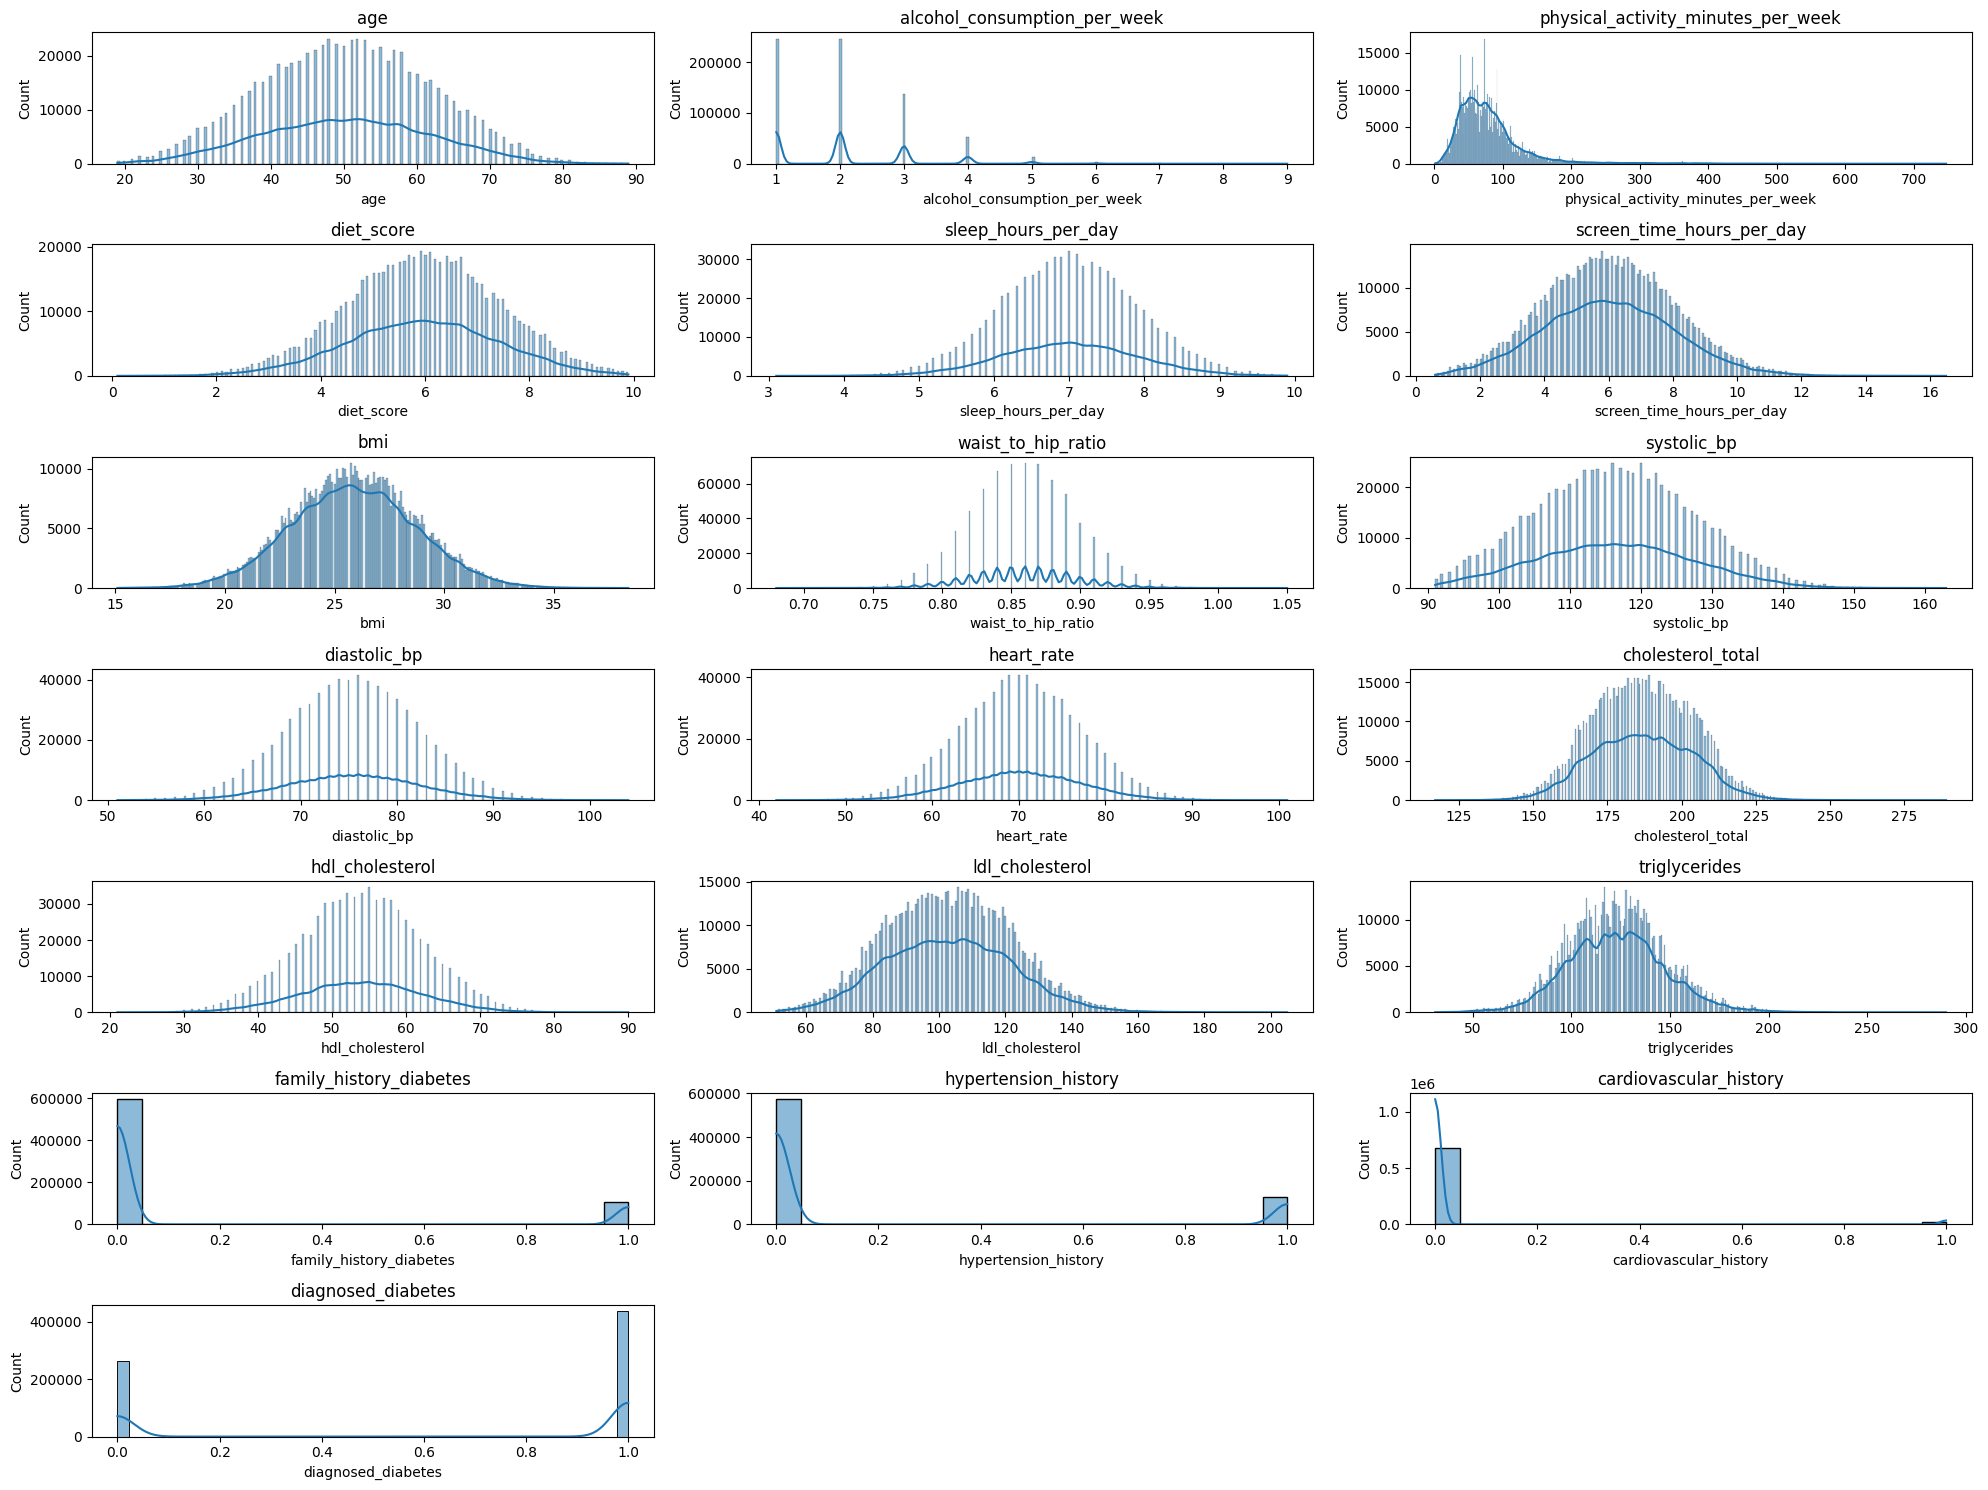

In [10]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(num_cols, 1):
    plt.subplot(7,3,i)
    sns.histplot(data[col], kde = True)
    plt.title(col)

plt.tight_layout()
plt.show()
    

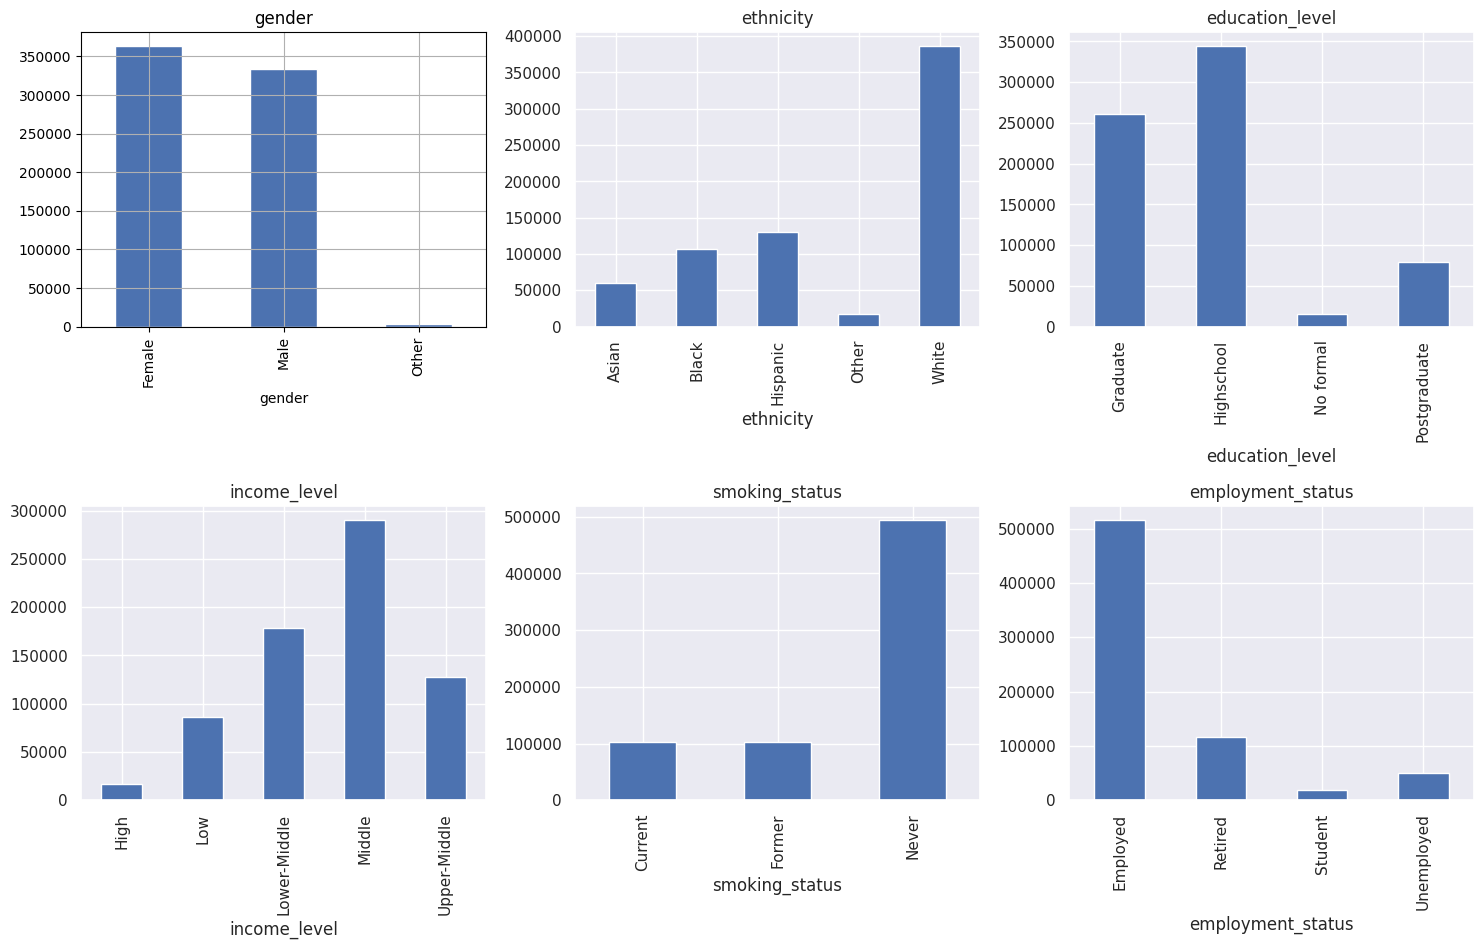

In [11]:
plt.figure(figsize=(15,13))
for i, col in enumerate(str_cols, 1):
    plt.subplot(3,3, i)
    sns.set(style='darkgrid')
    gen = data.groupby(col).size()
    gen.plot.bar(stacked=True)
    plt.title(col)
plt.tight_layout()
plt.show()

In [12]:
from sklearn.preprocessing import OrdinalEncoder

def encoder(str_cols, df):
    data = df
    for col in str_cols:
        ord1 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

        # Fit on a DataFrame (2D)
        ord1.fit(data[[col]])

        # Transform using the same shape
        data[col] = ord1.transform(data[[col]]).astype(int)
        
    return data


# data = pd.get_dummies(data, prefix=str_cols, columns=str_cols)
# data.head(10)

In [13]:
data = encoder(str_cols, data)
data.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,0,2,1,2,0,0,0,0,0,1.0
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,0,4,1,4,2,0,0,0,0,1.0
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,1,2,1,2,2,1,0,0,0,0.0
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,0,4,1,2,0,0,0,1,0,1.0
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,1,4,1,4,2,1,0,1,0,1.0


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


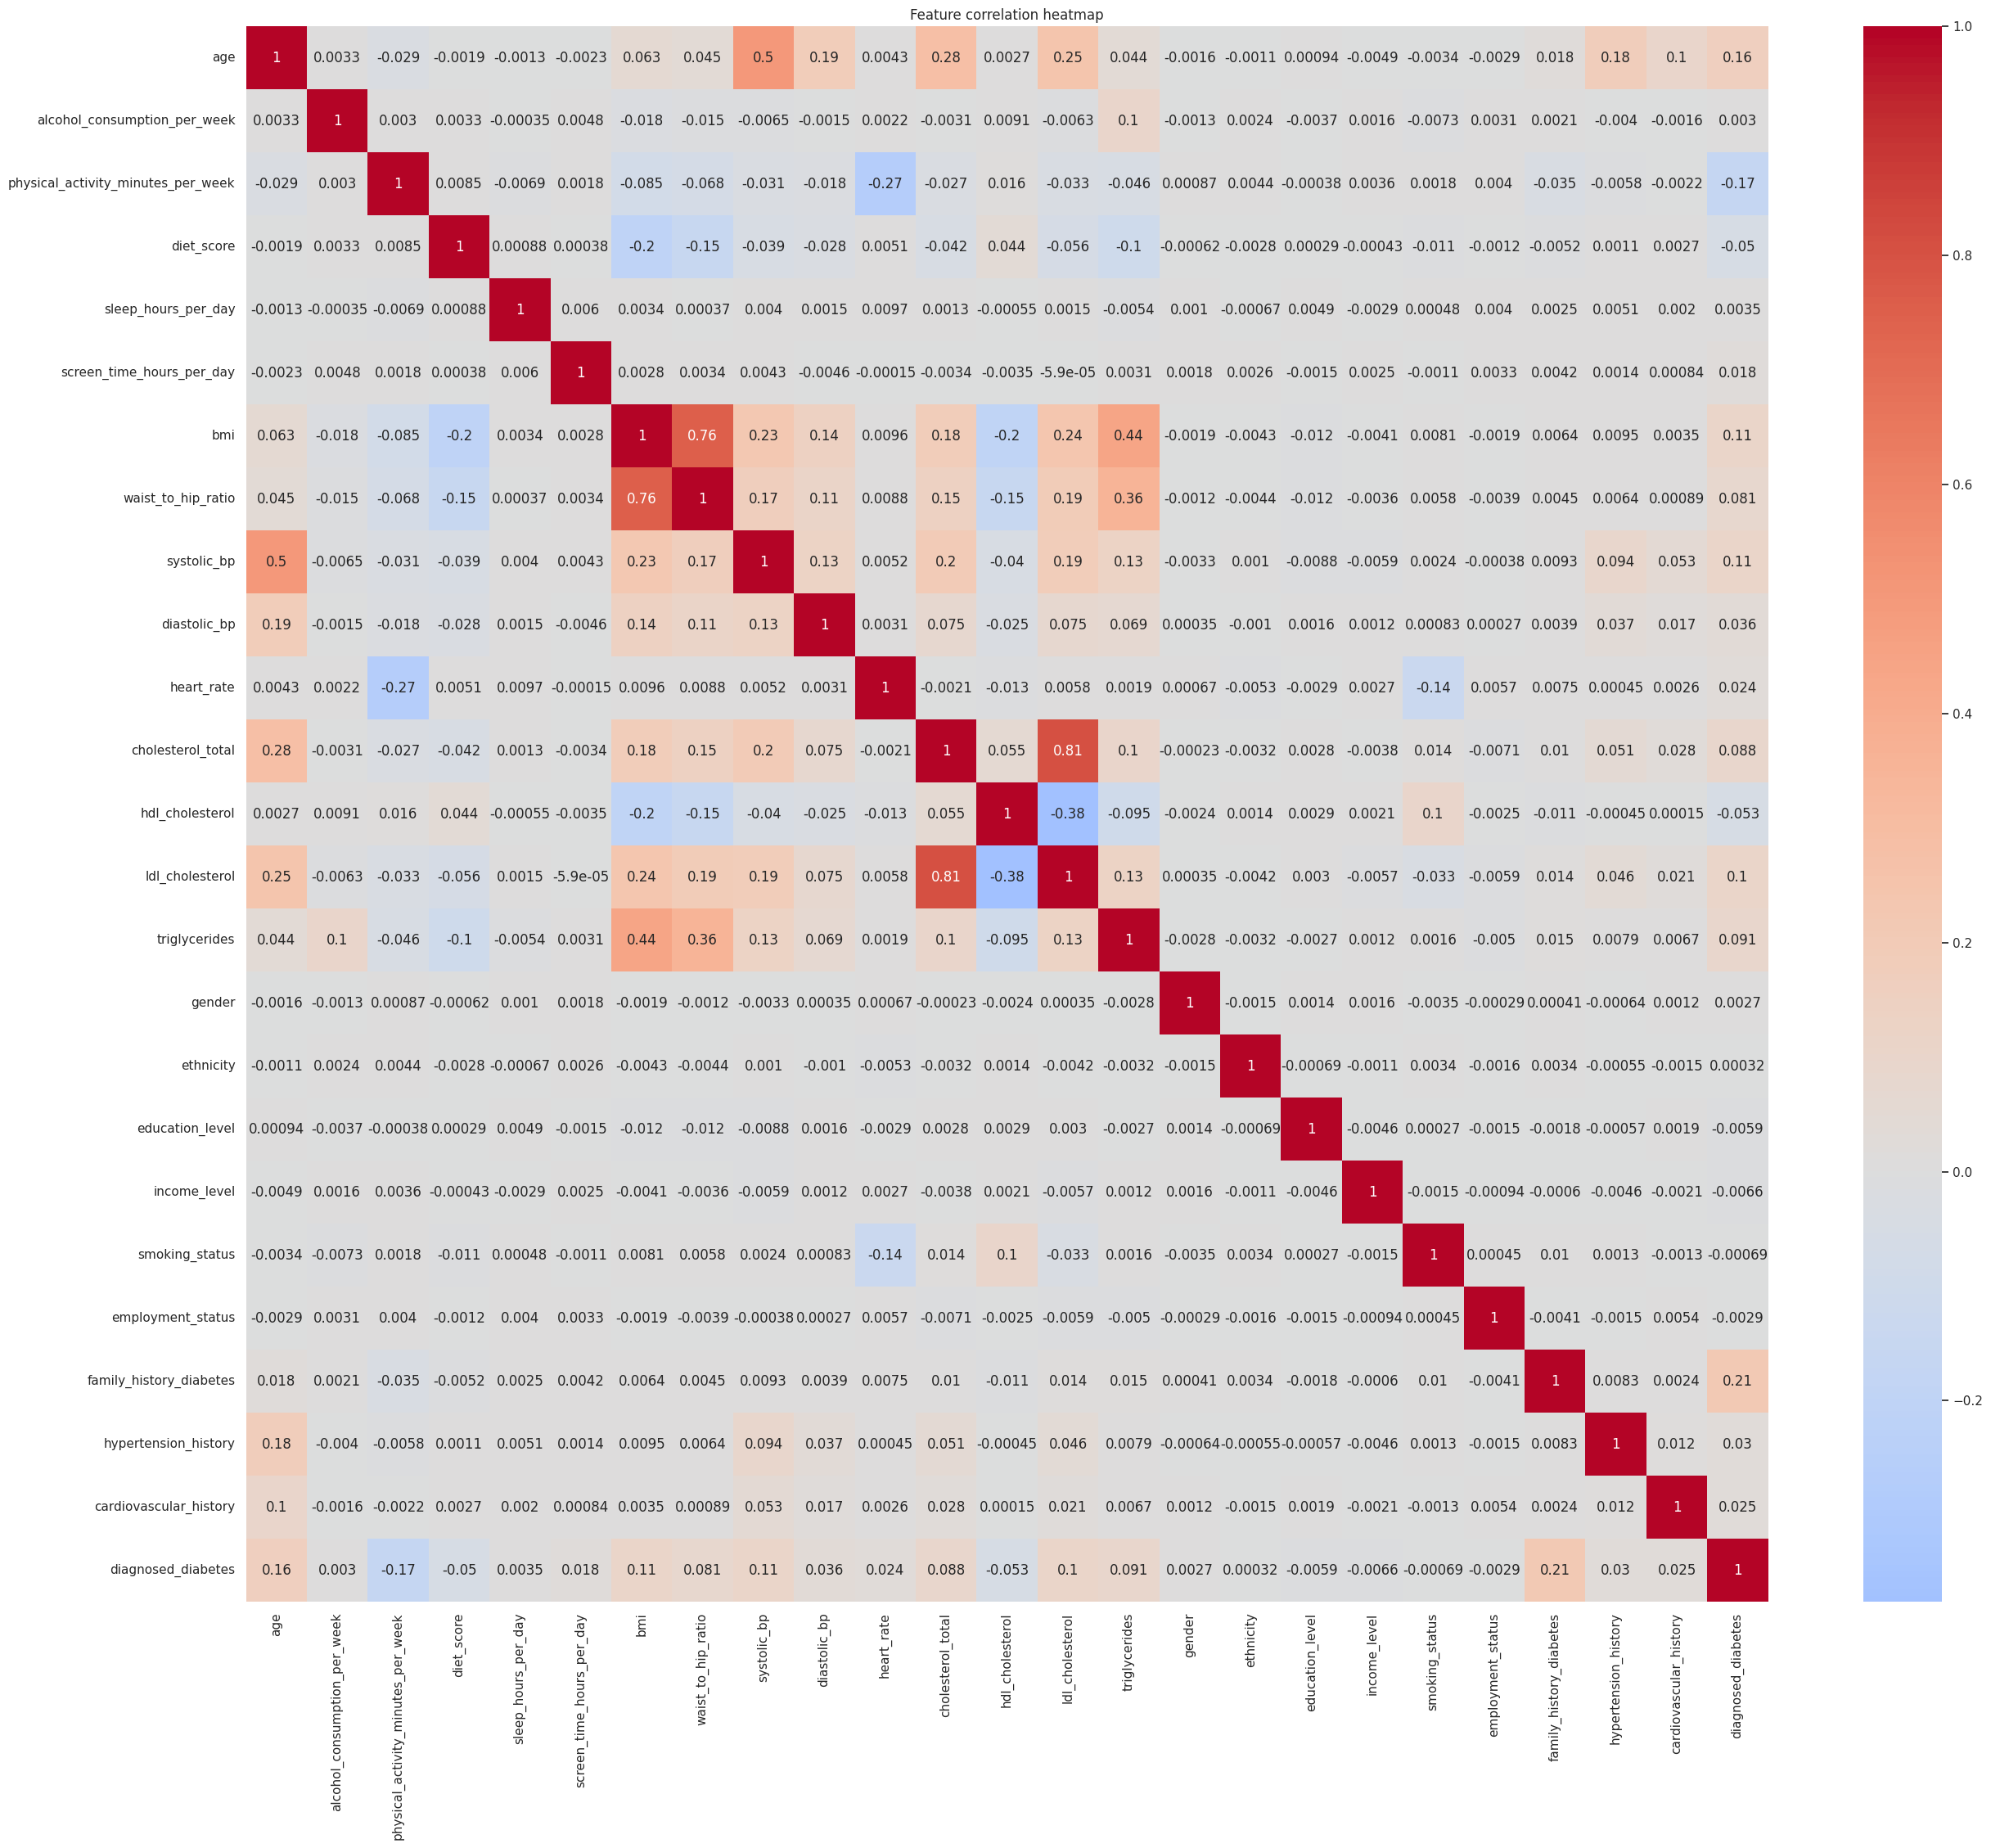

In [14]:
#heatmap
plt.figure(figsize=(30,25))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.show()

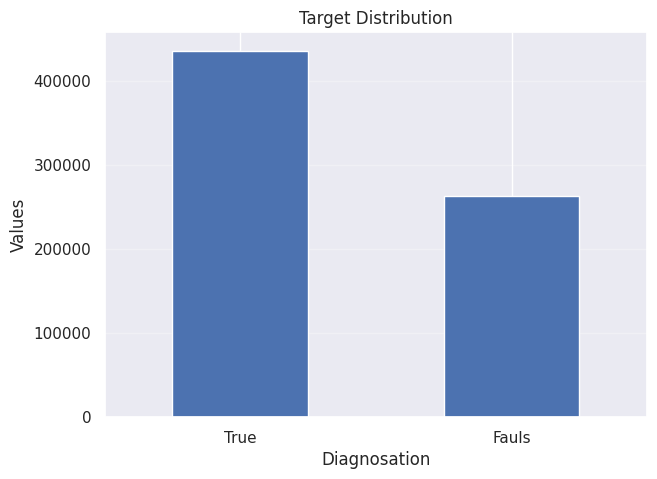

In [15]:
plt.figure(figsize=(7, 5))
data['diagnosed_diabetes'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('Diagnosation')
plt.ylabel("Values")
plt.xticks([0,1], ['True', "Fauls"], rotation = 0)
plt.grid(axis = 'y', alpha = 0.3)
plt.show()

In [16]:
#Applying the model .drop('diagnosed_diabetes',axis = 1) #
X = data.drop('diagnosed_diabetes',axis = 1) #[['age', 'bmi','systolic_bp', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'screen_time_hours_per_day','cholesterol_total', 'heart_rate']]
y = data['diagnosed_diabetes']

X_train,X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.fit_transform(X_test)

model  = LogisticRegression(max_iter = 200, random_state = 42)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=200, random_state=42)

In [17]:
print("Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {model.intercept_[0]:.4f}")

Model Coefficients:
age: 0.3110
alcohol_consumption_per_week: 0.0017
physical_activity_minutes_per_week: -0.3628
diet_score: -0.0716
sleep_hours_per_day: 0.0031
screen_time_hours_per_day: 0.0396
bmi: 0.1021
waist_to_hip_ratio: -0.0030
systolic_bp: 0.0210
diastolic_bp: -0.0169
heart_rate: -0.0526
cholesterol_total: 0.0311
hdl_cholesterol: -0.0608
ldl_cholesterol: 0.0515
triglycerides: 0.1057
gender: 0.0080
ethnicity: 0.0007
education_level: -0.0102
income_level: -0.0110
smoking_status: -0.0064
employment_status: -0.0011
family_history_diabetes: 0.5625
hypertension_history: 0.0015
cardiovascular_history: 0.0225
Intercept: 0.5855


In [18]:
#predict 

pred = model.predict(X_test_scaled)

In [19]:
print("First 3 predictions:", pred[:3])
print("\nFirst 3 real state:", y_test[:3])

First 3 predictions: [0. 1. 0.]

First 3 real state: 637949    1.0
656465    0.0
337739    1.0
Name: diagnosed_diabetes, dtype: float64


In [20]:
# evaluation
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
print("Accuracy:", accuracy)
print('precision', precision)
print("F1:", f1)
print('recall:', recall)

print("\nClassification report:")
print(classification_report(y_test, pred))

Accuracy: 0.6613785714285715
precision 0.6805123943051239
F1: 0.7606516986676226
recall: 0.8621853933227273

Classification report:
              precision    recall  f1-score   support

         0.0       0.59      0.33      0.42     52629
         1.0       0.68      0.86      0.76     87371

    accuracy                           0.66    140000
   macro avg       0.63      0.60      0.59    140000
weighted avg       0.65      0.66      0.63    140000



<Figure size 800x600 with 0 Axes>

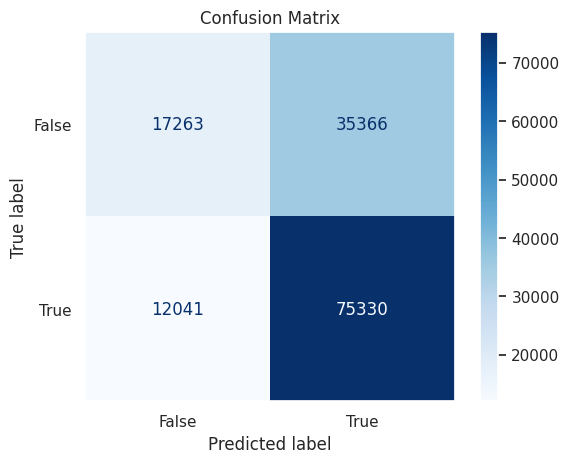


Confusion Matrix Components:
True Positives (TP): 75330 - Correctly predicted as approved
True Negatives (TN): 17263 - Correctly predicted as rejected
False Positives (FP): 35366 - Incorrectly predicted as approved (Type I error)
False Negatives (FN): 12041 - Incorrectly predicted as rejected (Type II error)


In [21]:
# Compute and visualize the confusion matrix
cm = confusion_matrix(y_test, pred)
cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['False', 'True']
)

plt.figure(figsize=(8, 6))
cmd.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

# Explain the confusion matrix components
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Components:")
print(f"True Positives (TP): {tp} - Correctly predicted as approved")
print(f"True Negatives (TN): {tn} - Correctly predicted as rejected")
print(f"False Positives (FP): {fp} - Incorrectly predicted as approved (Type I error)")
print(f"False Negatives (FN): {fn} - Incorrectly predicted as rejected (Type II error)")

,importance,total_%
family_history_diabetes,0.302724,30.3
physical_activity_minutes_per_week,0.195244,49.8
age,0.167389,66.5
triglycerides,0.056895,72.2
bmi,0.054930,77.7
diet_score,0.038514,81.6
hdl_cholesterol,0.032703,84.8
heart_rate,0.028286,87.7
ldl_cholesterol,0.027714,90.4
screen_time_hours_per_day,0.021301,92.6


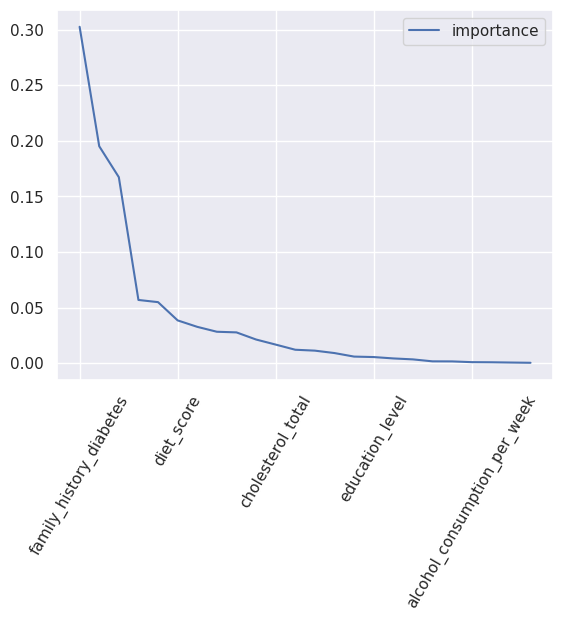

In [22]:
coefs = pd.DataFrame(data=model.coef_[0],
                     index= X.columns,
                     columns=['importance']).abs().sort_values(by=['importance'],ascending=False)
coefs['importance'] /= coefs['importance'].sum()  #L1 normalization
coefs.plot(rot=60)
coefs['total_%'] = coefs['importance'].cumsum().round(3)*100
coefs

In [23]:
important_features = coefs[coefs['importance']*100>=0.9] #.index.to_list()
important_features

,importance,total_%
family_history_diabetes,0.302724,30.3
physical_activity_minutes_per_week,0.195244,49.8
age,0.167389,66.5
triglycerides,0.056895,72.2
bmi,0.054930,77.7
diet_score,0.038514,81.6
hdl_cholesterol,0.032703,84.8
heart_rate,0.028286,87.7
ldl_cholesterol,0.027714,90.4
screen_time_hours_per_day,0.021301,92.6


In [24]:
X = data[important_features.index.to_list()]
X.head()

,family_history_diabetes,physical_activity_minutes_per_week,age,triglycerides,bmi,diet_score,hdl_cholesterol,heart_rate,ldl_cholesterol,screen_time_hours_per_day,cholesterol_total,cardiovascular_history,systolic_bp,diastolic_bp
0,0,45,31,102,33.4,7.7,58,62,114,6.1,199,0,112,70
1,0,73,50,124,23.8,5.7,50,71,121,5.8,199,0,120,77
2,0,158,32,108,24.1,8.5,59,73,114,9.1,188,0,95,89
3,0,77,54,123,26.6,4.6,54,74,85,9.2,182,0,121,69
4,0,55,54,124,28.8,5.7,49,85,131,5.1,206,0,108,60


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.fit_transform(X_test)

In [26]:
k = 5  
kf = KFold(n_splits=k, shuffle=True, random_state=42)

In [27]:
# Initialize the LogisticRegression model
model = LogisticRegression(max_iter = 200, random_state = 42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=200, random_state=42)

In [28]:
# Perform Cross Validation
scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='accuracy')

print(f"Accuracy for each fold: {scores}")

average_accuracy = np.mean(scores) 
print(f"Average Accuracy: {average_accuracy:.2f}")

Accuracy for each fold: [0.66255556 0.66626984 0.66427778 0.66111905 0.66203175]
Average Accuracy: 0.66


In [29]:
train_pred = model.predict(X_train_scaled)
accuracy = accuracy_score(train_pred, y_train)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.6632809523809524


In [30]:
test_path = "/kaggle/input/playground-series-s5e12/test.csv"
test = pd.read_csv(test_path)

In [31]:
test.shape

(300000, 25)

In [32]:
test = encoder(str_cols, test)
test.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history
0,700000,45,4,100,4.3,6.8,6.2,25.5,0.84,123,...,111,0,4,1,3,1,0,0,0,0
1,700001,35,1,87,3.5,4.6,9.0,28.6,0.88,120,...,145,0,4,1,3,2,3,0,0,0
2,700002,45,1,61,7.6,6.8,7.0,28.5,0.94,112,...,184,1,4,1,1,2,0,0,0,0
3,700003,55,2,81,7.3,7.3,5.0,26.9,0.91,114,...,128,1,4,0,3,1,0,0,0,0
4,700004,77,2,29,7.3,7.6,8.5,22.0,0.83,131,...,133,1,4,0,1,0,3,0,0,0


In [33]:
test.drop('id', axis = 1)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history
0,45,4,100,4.3,6.8,6.2,25.5,0.84,123,70,...,111,0,4,1,3,1,0,0,0,0
1,35,1,87,3.5,4.6,9.0,28.6,0.88,120,74,...,145,0,4,1,3,2,3,0,0,0
2,45,1,61,7.6,6.8,7.0,28.5,0.94,112,71,...,184,1,4,1,1,2,0,0,0,0
3,55,2,81,7.3,7.3,5.0,26.9,0.91,114,81,...,128,1,4,0,3,1,0,0,0,0
4,77,2,29,7.3,7.6,8.5,22.0,0.83,131,78,...,133,1,4,0,1,0,3,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,59,3,185,6.3,7.3,4.4,22.8,0.81,108,75,...,126,1,4,1,4,1,0,1,0,0
299996,50,2,25,5.8,7.8,4.5,29.6,0.93,112,70,...,112,1,0,3,2,2,0,0,0,0
299997,63,1,252,5.2,7.5,8.5,25.1,0.77,129,63,...,135,0,4,1,3,2,0,0,0,0
299998,48,3,72,4.9,6.9,1.8,27.7,0.89,121,67,...,138,1,4,1,1,0,1,0,1,0


In [34]:
# X_test = test.drop('diagnosed_diabetes',axis = 1)  
X_test = test[important_features.index.to_list()]
x_test_scaled = scaler.fit_transform(X_test)

In [35]:
test_pred = model.predict(x_test_scaled)

In [36]:
submission_data = pd.DataFrame({
        "id": test['id'],
        "diagnosed_diabetes": test_pred
})

In [37]:
submission_data.head()

,id,diagnosed_diabetes
0,700000,1.0
1,700001,1.0
2,700002,1.0
3,700003,1.0
4,700004,1.0


In [38]:
submission_data.to_csv('submission.csv', index = False)